# The AI Telco Troubleshooting Challenge

Goal: Enhance the accuracy of Qwen2.5-1.5B when answering telco troubleshooting questions in telelogs data.

## I/ Set-up

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1778858230.380235    3162 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[]


E0000 00:00:1778858245.195921    3162 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1778858245.196063    3162 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1778858245.196087    3162 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1778858245.196110    3162 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1778858245.196114    3162 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: vscode-pytorch-gpu-34026-0
I0000 00:00:1778858245.196122    3162 cuda_diagnostics.cc:183] hostname: vscode-pytorch-gpu-34026-0
I0000 00:00:1778858245.196486    3162 cuda_diagnostics.cc:190] libcuda reported version is: 575.57.8
I0000 00:00:1778858245.196596    3162 c

### 1. Load libraries

In [3]:
import pandas as pd
import numpy as np
import re
import random
from io import StringIO

### 2.Load data

In [4]:
#load data
df = pd.read_csv("/home/onyxia/work/Telco-challenge/data/raw/train.csv")
print(df.head())
print(f"Number of rows {df.shape[0]}")

              ID                                           question answer
0  ID_1P7PJMPV0R  Analyze the 5G wireless network drive-test use...     C2
1  ID_8B1D1TUTFA  Analyze the 5G wireless network drive-test use...     C1
2  ID_IGGXMA9GZH  Analyze the 5G wireless network drive-test use...     C2
3  ID_D6C9N2X295  Analyze the 5G wireless network drive-test use...     C2
4  ID_8JC15PNP3Q  Analyze the 5G wireless network drive-test use...     C5
Number of rows 2400


In [5]:
print(df["question"][0])

Analyze the 5G wireless network drive-test user plane data and engineering parameters.
Identify the reason for the throughput dropping below 600Mbps in certain road sections.
From the following 8 potential root causes, select the most likely one and enclose its number in \boxed{{}} in the final answer.

C1: The serving cell's downtilt angle is too large, causing weak coverage at the far end.
C2: The serving cell's coverage distance exceeds 1km, resulting in over-shooting.
C3: A neighboring cell provides higher throughput.
C4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.
C5: Frequent handovers degrade performance.
C6: Neighbor cell and serving cell have the same PCI mod 30, leading to interference.
C7: Test vehicle speed exceeds 40km/h, impacting user throughput.
C8: Average scheduled RBs are below 160, affecting throughput.

Given:
- The default electronic downtilt value is 255, representing a downtilt angle of 6 degrees. Other values represent the ac

**Game plan**
We have time series in drive test data: multiple timestamps by telelog Id and engineering data linked to PCI that we also find in the drive test data so:

1) Parse "question" columns into two categories of features: drive test and engineering. Then merge to have a final dataframe which is a structured like a time series.
2) Train time series/sequential ML models on the features to predict root cause
3) If possible fine-tune an LLM to find the root cause directly from the "question" columns
4) Compare both approaches

### 3.Preprocess data

In [6]:
class Preprocessor():

    def __init__(self, question):

        self.question = question

    def parse_question(self):
        """
        Divide question into:
        - drive test dataframe
        - engineering dataframe
        """

        # Split sections
        parts = self.question.split(
            "Engeneering parameters data as follows："
        )

        drive_part = parts[0]
        eng_part = parts[1]

        # -------------------------
        # DRIVE TEST TABLE
        # -------------------------

        drive_lines = []

        started = False

        for line in drive_part.split("\n"):

            if "Timestamp|" in line:
                started = True

            if started and "|" in line:
                drive_lines.append(line)

        drive_text = "\n".join(drive_lines)

        drive_df = pd.read_csv(
            StringIO(drive_text),
            sep="|"
        )
        drive_df.columns = drive_df.columns.str.strip()
         # replace "-" with NaN
        drive_df = drive_df.replace("-", np.nan)
        for col in [c for c in drive_df.columns if c!="Timestamp"]:
            drive_df[col] = pd.to_numeric(
                drive_df[col],
                errors="coerce"
            )
        # -------------------------
        # ENGINEERING TABLE
        # -------------------------

        eng_lines = []

        started = False

        for line in eng_part.split("\n"):

            if "gNodeB ID|" in line:
                started = True

            if started and "|" in line:
                eng_lines.append(line)

        eng_text = "\n".join(eng_lines)

        eng_df = pd.read_csv(
            StringIO(eng_text),
            sep="|"
        )
        eng_df.columns = eng_df.columns.str.strip()
         # replace "-" with NaN
        eng_df = eng_df.replace("-", np.nan)
        for col in ["Cell ID", "Longitude", "Latitude", "Mechanical Azimuth", "Mechanical Downtilt", "Digital Tilt", "Digital Azimuth", "Height", "PCI", "Max Transmit Power"]:
            eng_df[col] = pd.to_numeric(
                eng_df[col],
                errors="coerce"
            )
        return drive_df, eng_df

    def merge_features(self, drive_df, eng_df):
        """
        Merge categories of features into one dataframe
        """

        merged = drive_df.merge(
            eng_df,
            left_on="5G KPI PCell RF Serving PCI",
            right_on="PCI",
            how="left"
        )

        return merged

    def build_sequence(self):

        """
        Transform the dataframes into one row by telelog id
        """

        drive_df, eng_df = self.parse_question()

        merged = self.merge_features(
            drive_df,
            eng_df
        )
        merged.columns = merged.columns.str.strip()
       

        # convert numeric
        merged["Timestamp"] = pd.to_datetime(merged["Timestamp"])

        return merged

In [7]:
#Let's preprocess data
processed_rows = []
for idx, row in df.iterrows():
    try:
        processor = Preprocessor(row["question"])
        merged = processor.build_sequence()
        merged["ID"] = row["ID"]
        # store tabular version
        processed_rows.append(merged)
    except Exception as e:
        print(f"Error on row {idx}: {e}")

# build final dataframe ONCE (important)
processed_dataframe = pd.concat(processed_rows, ignore_index=True)
processed_dataframe.head()

,Timestamp,Longitude_x,Latitude_x,GPS Speed (km/h),5G KPI PCell RF Serving PCI,5G KPI PCell RF Serving SS-RSRP [dBm],5G KPI PCell RF Serving SS-SINR [dB],5G KPI PCell Layer2 MAC DL Throughput [Mbps],Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI,Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI,...,Mechanical Downtilt,Digital Tilt,Digital Azimuth,Beam Scenario,Height,PCI,TxRx Mode,Max Transmit Power,Antenna Model,ID
0,2025-05-07 15:23:52,128.188169,32.579273,1,712,-77.00,15.93,1351.25,258,71,...,6.0,4.0,0.0,DEFAULT,5.0,712.0,64T64R,34.9,NR AAU 2,ID_1P7PJMPV0R
1,2025-05-07 15:23:53,128.188140,32.579223,2,71,-80.97,6.60,366.57,258,712,...,3.0,10.0,0.0,DEFAULT,29.7,71.0,32T32R,34.9,NR AAU 1,ID_1P7PJMPV0R
2,2025-05-07 15:23:54,128.188117,32.579174,16,71,-85.50,1.81,334.00,258,712,...,3.0,10.0,0.0,DEFAULT,29.7,71.0,32T32R,34.9,NR AAU 1,ID_1P7PJMPV0R
3,2025-05-07 15:23:55,128.188103,32.579113,14,71,-88.21,5.40,431.94,712,258,...,3.0,10.0,0.0,DEFAULT,29.7,71.0,32T32R,34.9,NR AAU 1,ID_1P7PJMPV0R
4,2025-05-07 15:23:56,128.188088,32.579075,19,71,-78.45,13.59,566.34,712,258,...,3.0,10.0,0.0,DEFAULT,29.7,71.0,32T32R,34.9,NR AAU 1,ID_1P7PJMPV0R


In [8]:
print(f"Data frame size: {processed_dataframe.shape}")

Data frame size: (24000, 34)


### 4. Feature selection 

In [9]:
#Rename columns
processed_dataframe=processed_dataframe.rename({"Longitude_x": "Longitude", "Latitude_x":"Latitude", "Longitude_y": "cell_Longitude","Latitude_y": "cell_Latitude"},axis="columns")
processed_dataframe.columns

Index(['Timestamp', 'Longitude', 'Latitude', 'GPS Speed (km/h)',
       '5G KPI PCell RF Serving PCI', '5G KPI PCell RF Serving SS-RSRP [dBm]',
       '5G KPI PCell RF Serving SS-SINR [dB]',
       '5G KPI PCell Layer2 MAC DL Throughput [Mbps]',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm]',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]',
       'Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]',
       'Measurement PCell 

In [10]:
#¨Percentage of missing values by column
processed_dataframe.isna().sum() / len(processed_dataframe)

Timestamp                                                                            0.000000
Longitude                                                                            0.000000
Latitude                                                                             0.000000
GPS Speed (km/h)                                                                     0.000000
5G KPI PCell RF Serving PCI                                                          0.000000
5G KPI PCell RF Serving SS-RSRP [dBm]                                                0.000000
5G KPI PCell RF Serving SS-SINR [dB]                                                 0.000000
5G KPI PCell Layer2 MAC DL Throughput [Mbps]                                         0.000000
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI                        0.000000
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI                        0.000000
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PC

We won't columns with more than 40% missing values:
- Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI
- Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI  
- Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI
- Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]    
- Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]    
- Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]    

In [11]:
#Sort dataframe
processed_dataframe=processed_dataframe.drop(columns=["Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI",
"Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI", 
"Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI",
"Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]",    
"Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]",    
"Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]","gNodeB ID","Cell ID"]).sort_values(by=["ID","Timestamp"])
#Replace missing values by the previous or following value
ids = processed_dataframe["ID"]
processed_dataframe = processed_dataframe.groupby("ID").ffill().bfill()
processed_dataframe["ID"] = ids

In [12]:
#Check na
processed_dataframe.isna().sum() / len(processed_dataframe)

Timestamp                                                                            0.0
Longitude                                                                            0.0
Latitude                                                                             0.0
GPS Speed (km/h)                                                                     0.0
5G KPI PCell RF Serving PCI                                                          0.0
5G KPI PCell RF Serving SS-RSRP [dBm]                                                0.0
5G KPI PCell RF Serving SS-SINR [dB]                                                 0.0
5G KPI PCell Layer2 MAC DL Throughput [Mbps]                                         0.0
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI                        0.0
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI                        0.0
Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]    0.0
Measurement PCell Nei

### 5. Modeling

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout,Input,Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, train_test_split,cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import make_scorer ,confusion_matrix,classification_report
import keras_tuner as kt

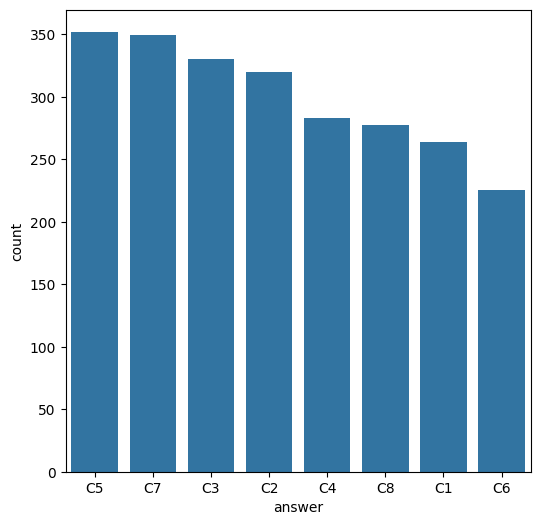

In [14]:
#Plotting target variable
plt.figure(figsize=(6, 6))
sns.barplot(x = "answer", y="count",data=pd.DataFrame(df.value_counts("answer").reset_index()))
plt.show()

Not unbalanced

**Format dataframe**

In [15]:
#Format data
processed_data = []
for telelog_id in processed_dataframe["ID"].unique():
    # get rows for ONE telelog
    sample_df = processed_dataframe[
        processed_dataframe["ID"] == telelog_id
    ].copy()

    # sort by time
    sample_df = sample_df.sort_values("Timestamp").drop(columns=["Timestamp"])
    for col in sample_df.columns[sample_df.columns.isin(sample_df.select_dtypes(include=["object", "string"]).columns)]:
        le = LabelEncoder()
        sample_df[col] = le.fit_transform(sample_df[col])

    # sequence = matrix
    sequence = sample_df.values

    # get label
    label = df[df["ID"] == telelog_id]["answer"].iloc[0]

    processed_data.append({
        "ID": telelog_id,
        "sequence": sequence,
        "label": label
    })

label_map = {
    "C1":0,
    "C2":1,
    "C3":2,
    "C4":3,
    "C5":4,
    "C6":5,
    "C7":6,
    "C8":7}
for sample in processed_data:
    sample["label_id"] = label_map[sample["label"]]

sequences = [
    sample["sequence"]
    for sample in processed_data
]
labels = [
    sample["label_id"]
    for sample in processed_data
]

In [16]:
# Padding
X = pad_sequences(sequences).astype("float32")
#one hot encoding
y = to_categorical(labels, num_classes=8)
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
print("X_train:", X_train.shape)
print("y_train:", len(y_train))
print("X_test:", X_test.shape)
print("y_test:", len(y_test))

X_train: (1920, 10, 25)
y_train: 1920
X_test: (480, 10, 25)
y_test: 480


**Building the model**

In [17]:
def build_model(hp):

    model = Sequential()

    # ✅ Always start with Input layer (IMPORTANT for Keras Tuner stability)
    model.add(Input(shape=(10, 25)))

    # LSTM layer
    model.add(
        LSTM(
            units=hp.Choice("lstm_units", [64, 128,256]),
            return_sequences=False
        )
    )

    # Dropout (kept optional but stable)
    model.add(
        Dropout(
            rate=hp.Choice("dropout", [0.0,0.1, 0.2,0.3,0.4 0.5])
        )
    )

    # Dense layer
    model.add(
        Dense(
            units=hp.Choice("dense_units", [32, 64,128]),
            activation="relu"
        )
    )

    # Output layer
    model.add(Dense(8, activation="softmax"))

    # Learning rate tuning
    lr = hp.Choice("lr", [1e-3, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy",]
    )

    return model

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2978229040.py, line 19)

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    directory="tuning",
    project_name="telecom_lstm"
)

tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Reloading Tuner from tuning/telecom_lstm/tuner0.json


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]

/home/onyxia/work/Telco-challenge/telco_env/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Evaluate
loss, accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4000 - loss: 1.5450
Test Accuracy: 0.40


In [ ]:
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(np.argmax(y_test, axis=1), y_pred_classes))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.86      0.43      0.57        56
           2       0.16      0.07      0.09        61
           3       0.65      0.75      0.70        53
           4       0.12      0.04      0.06        79
           5       0.56      0.98      0.71        43
           6       0.21      0.77      0.33        62
           7       0.82      0.57      0.67        54

    accuracy                           0.40       480
   macro avg       0.42      0.45      0.39       480
weighted avg       0.38      0.40      0.35       480



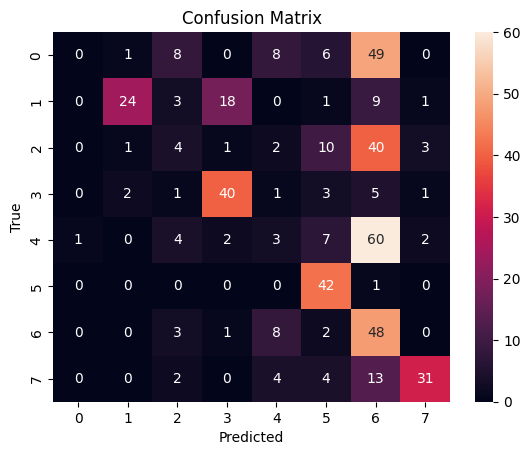

In [ ]:
sns.heatmap(confusion_matrix(np.argmax(y_test, axis=1), y_pred_classes), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
a

Seems like the dataset is unbalanced after all

Let's fit the model with F1 as referential metrics and adding class weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
#Let's add weights
y_train_labels = np.argmax(y_train, axis=-1).flatten()
classes = np.unique(y_train_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_labels
)

class_weights = dict(zip(classes, class_weights))

In [ ]:
class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes=8, name="f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes

        self.conf_matrix = self.add_weight(
            name="conf_matrix",
            shape=(num_classes, num_classes),
            initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.argmax(y_true, axis=1)
        y_pred = tf.argmax(y_pred, axis=1)

        cm = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes
        )

        self.conf_matrix.assign_add(tf.cast(cm, tf.float32))

    def result(self):
        cm = self.conf_matrix

        tp = tf.linalg.diag_part(cm)
        fp = tf.reduce_sum(cm, axis=0) - tp
        fn = tf.reduce_sum(cm, axis=1) - tp

        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)

        f1 = 2 * precision * recall / (precision + recall + 1e-7)

        return tf.reduce_mean(f1)

    def reset_state(self):
        self.conf_matrix.assign(tf.zeros_like(self.conf_matrix))

In [ ]:
def build_model_f1(hp):

    model = Sequential()

    # ✅ Always start with Input layer (IMPORTANT for Keras Tuner stability)
    model.add(Input(shape=(10, 25)))

    # LSTM layer
    model.add(
        LSTM(
            units=hp.Choice("lstm_units", [64, 128,256]),
            return_sequences=False
        )
    )

    # Dropout (kept optional but stable)
    model.add(
        Dropout(
            rate=hp.Choice("dropout", [0.0, 0.1, 0.2,0.3,0.4, 0.5])
        )
    )

    # Dense layer
    model.add(
        Dense(
            units=hp.Choice("dense_units", [32, 64,128]),
            activation="relu"
        )
    )

    # Output layer
    model.add(Dense(8, activation="softmax"))

    # Learning rate tuning
    lr = hp.Choice("lr", [1e-3, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy",MacroF1(num_classes=8, name="f1")]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model_f1,
    objective = kt.Objective("val_f1", direction="max"),
    max_trials=10,
    directory="tuning",
    project_name="telecom_lstm",
    overwrite=True
)
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights
)
best_model_w = tuner.get_best_models(num_models=1)[0]

Trial 10 Complete [00h 01m 13s]
val_f1: 0.7514718174934387

Best val_f1 So Far: 0.7795852422714233
Total elapsed time: 00h 13m 46s


/home/onyxia/work/Telco-challenge/telco_env/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
y_pred_w = best_model_w.predict(X_test)
y_pred_classes_w = np.argmax(y_pred_w, axis=1)

print(classification_report(np.argmax(y_test, axis=1), y_pred_classes_w))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

           0       0.47      0.54      0.50        72
           1       0.98      0.88      0.92        56
           2       0.51      0.80      0.62        61
           3       0.90      0.98      0.94        53
           4       0.41      0.18      0.25        79
           5       1.00      1.00      1.00        43
           6       1.00      1.00      1.00        62
           7       1.00      1.00      1.00        54

    accuracy                           0.75       480
   macro avg       0.78      0.80      0.78       480
weighted avg       0.75      0.75      0.74       480



Next step: redo the weights

In [ ]:
# #Function to clean questions
# def clean_question(question):
#     lines=question.split("\n")
#     content=[]
#     for line in lines:
#         if "|" in line:
#             content.append(line.split("|"))
#     drive_test_data=[{"Observation": i+1,**dict(zip(content[0],row))} for i,row in enumerate(content[1:])]
#     engineering_params=[{"Observation": i+1,**dict(zip(content[11],row))} for i,row in enumerate(content[12:])]
#     #clean question
#     ##recompute begining of the prompt
#     q=""
#     for l in [l+"\n" for l in lines[:19]]:
#         q=q+l
#     ##assemble
#     cleaned_question= f" Question: {q} \nDrive test data: {drive_test_data} \nEngineering parameters {engineering_params} "
#     return cleaned_question
# #Apply to dataset
# df["cleaned_question"]=df["question"].apply(lambda x: clean_question(x))
# print(df["cleaned_question"][0])

In [ ]:
def compute_features(question):
    def extract_features(question):
        lines = question.split("\n")
        content = []
        for line in lines:
            if "|" in line:
                content.append(line.split("|"))
    
        headers = content[0]
        rows = content[1:11]  # only drive test rows
    
        drive_test = [dict(zip(headers, row)) for row in rows]
    
        return drive_test
    data = extract_features(question)
    
    # convert to numeric safely
    speeds = [float(d["GPS Speed (km/h)"]) for d in data]
    sinr = [float(d["5G KPI PCell RF Serving SS-SINR [dB]"]) for d in data]
    throughput = [float(d["5G KPI PCell Layer2 MAC DL Throughput [Mbps]"]) for d in data]
    rb = [float(d["5G KPI PCell Layer1 DL RB Num (Including 0)"]) for d in data]
    
    features = {
        "avg_speed": np.mean(speeds),
        "max_speed": np.max(speeds),
        "avg_sinr": np.mean(sinr),
        "min_sinr": np.min(sinr),
        "avg_throughput": np.mean(throughput),
        "min_throughput": np.min(throughput),
        "avg_rb": np.mean(rb),
        "min_rb": np.min(rb),
        "throughput_below_600_ratio": sum(t < 600 for t in throughput) / len(throughput),
    }
    
    return features
    def compute_engineering_features(question):
        params = extract_engineering_params(question)
        downtilts = []
        pcis = []
        heights = []
    
        for p in params:
            try:
                downtilt = float(p["Mechanical Downtilt"]) + float(p["Digital Tilt"])
                downtilts.append(downtilt)
            
                pcis.append(int(p["PCI"]))
                heights.append(float(p["Height"]))
            except:
                continue
    
        features = {
            "avg_downtilt": sum(downtilts)/len(downtilts) if downtilts else 0,
            "max_downtilt": max(downtilts) if downtilts else 0,
            "min_downtilt": min(downtilts) if downtilts else 0,
            "num_cells": len(params),
            "unique_pci": len(set(pcis)),
            "pci_mod30_conflict": len(set([p % 30 for p in pcis])) < len(pcis),
            "avg_height": sum(heights)/len(heights) if heights else 0
        }
    
    return features
    
features_df = df["question"].apply(compute_features).apply(pd.Series)

In [ ]:
features_df.columns

Index(['avg_speed', 'max_speed', 'avg_sinr', 'min_sinr', 'avg_throughput',
       'min_throughput', 'avg_rb', 'min_rb', 'throughput_below_600_ratio'],
      dtype='str')

## II/ Untrained model

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from dotenv import load_dotenv
import os
from datasets import Dataset

/home/onyxia/work/Telco-challenge/telco_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#empty cache
torch.cuda.empty_cache()
#set token 
load_dotenv("telco.env")
token = os.getenv("HF_TOKEN")

In [ ]:

# load the tokenizer and the model
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, token=token)
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="sequential",
    offload_folder="offload"
)
model.eval()

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 426.04it/s]


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

In [ ]:
def batch_predict(batch):
    questions = batch["cleaned_question"]

    prompts = [
        tokenizer.apply_chat_template(
            [{"role": "user", "content": q}],
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False
        )
        for q in questions
    ]

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=32
        )

    predictions = []

    for i in range(len(prompts)):
        decoded = tokenizer.decode(
            outputs[i][inputs["input_ids"][i].shape[0]:],
            skip_special_tokens=True
        )

        match = re.search(r"\b(C\d)\b", decoded)
        predictions.append(match.group(1) if match else "UNKNOWN")

    return {"root_cause": predictions}
      

In [ ]:
# Select rows to test model
df_test=df.iloc[[random.randint(0, 2400-1) for _ in range(10)]]
ds_test = Dataset.from_pandas(df_test)

In [ ]:
#predictions
ds_test = ds_test.map(
    batch_predict,
    batched=True,
    batch_size=8
)
#save dataset
ds_test.save_to_disk("checkpoint_ds")
df_test = ds_test.to_pandas()


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

In [ ]:
git add .

In [ ]:
git commit -m "Saved predictions to disk"

In [ ]:
git push

## III/ Fine-tune model

In [ ]:
import time
from sagemaker.huggingface import HuggingFace


job_name = f"mixtral-8x7b-qlora-{time.strftime('%Y-%m-%d-%H-%M-%S', time.localtime())}"

hyperparameters = {
    "model_id": model_id,
    "dataset_path": "/opt/ml/input/data/training",
    "epochs": 2,
    "per_device_train_batch_size": 2,
    "lr": 2e-4,
    "merge_weights": True,
}

huggingface_estimator = HuggingFace(
    entry_point = "run_clm.py",
    source_dir= "scripts",
    instance_type = "ml.g5.24xlarge",
    instance_count = 1,
    base_job_name = job_name,
    role = role,
    volume_size = 300,
    transformers_version= "4.28",
    pytorch_version= "2.0",
    py_version= "py310",
    hyperparameters = hyperparameters,
    environment = {
        "HUGGINGFACE_HUB_CACHE": "/tmp/.cache"

_IncompleteInputError: incomplete input (2506589804.py, line 29)

In [ ]:
data = {"training": training_input_path}
huggingface_estimator.fit(data,wait = True)